# Extreme Events Investigation

This notebook investigates two questions regarding extreme events (flagged as `outlier_lim = true`):
1. **Correlation with beekeeper observations:** Do extreme events correlate with swarming, feeding, honey harvest, treatment, or colony death?
2. **Date clustering:** Do extreme events cluster on certain dates across multiple hives (suggesting an external cause) or are they spread across the timeline per-hive?

In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

# Load environment variables
load_dotenv(dotenv_path="../.env")
quack_host = os.getenv("TAILNET_HOST")
quack_token = os.getenv("QUACK_TOKEN")

# Setup DuckDB
con = duckdb.connect('honey.duckdb')
con.execute("FORCE INSTALL quack")
con.execute("INSTALL httpfs")
con.execute("LOAD quack")
con.execute("LOAD httpfs")
con.execute("SET s3_region = 'us-east-1'")

con.execute(f"""
    ATTACH 'quack:{quack_host}' AS bees (
        TOKEN '{quack_token}',
        DISABLE_SSL true
    )
""")
print("Connected to Quack DB successfully.")

Connected to Quack DB successfully.


## 1. Load Data for Extreme Events

We fetch data using `bees.query` with explicit `CAST` to `VARCHAR` on certain columns to avoid DuckDB Quack extension `Vector::Reference` crashes.

In [2]:
# Query extreme events and related distance columns explicitly handled
query = """
SELECT * FROM bees.query('
    SELECT 
        outlier_lim, 
        CAST(time AS VARCHAR) as time, 
        key, 
        treatment_last_dif, treatment_next_dif, 
        died_last_dif, died_next_dif, 
        swarming_last_dif, CAST(swarming_next_dif AS VARCHAR) as swarming_next_dif, 
        CAST(feeding_last_dif AS VARCHAR) as feeding_last_dif, CAST(feeding_next_dif AS VARCHAR) as feeding_next_dif, 
        CAST(honey_last_dif AS VARCHAR) as honey_last_dif, CAST(honey_next_dif AS VARCHAR) as honey_next_dif
    FROM bob_sensor_processed 
    WHERE outlier_lim = true
')
"""

df_extreme = con.execute(query).fetchdf()

dif_cols = [
    'treatment_last_dif', 'treatment_next_dif',
    'died_last_dif', 'died_next_dif',
    'swarming_last_dif', 'swarming_next_dif',
    'feeding_last_dif', 'feeding_next_dif',
    'honey_last_dif', 'honey_next_dif'
]

for col in dif_cols:
    df_extreme[col] = pd.to_numeric(df_extreme[col], errors='coerce')

df_extreme['time'] = pd.to_datetime(df_extreme['time'])
print(f"Loaded {len(df_extreme)} extreme events.")

Loaded 98304 extreme events.


## 2. Correlation with Beekeeper Observations

To see if extreme weight jumps correlate with beekeeper observations, we look at the absolute time distance (in days) to the closest event for each category. If extreme events are caused by these observations, we expect a high concentration of distances near 0.

,Event,Median Dist (days),Mean Dist (days),% Within 1 Day,% Within 7 Days,Total Annotated Extremes
0,Treatment,874770.00,2144722.85,0.0,1.42,844
1,Died,348.22,203616.26,0.0,0.62,6926
2,Swarming,8595410.00,7704289.48,0.0,0.00,348
3,Feeding,2376840.00,2279669.15,0.0,0.13,10631
4,Honey,194340.00,3294200.55,0.0,0.03,21865


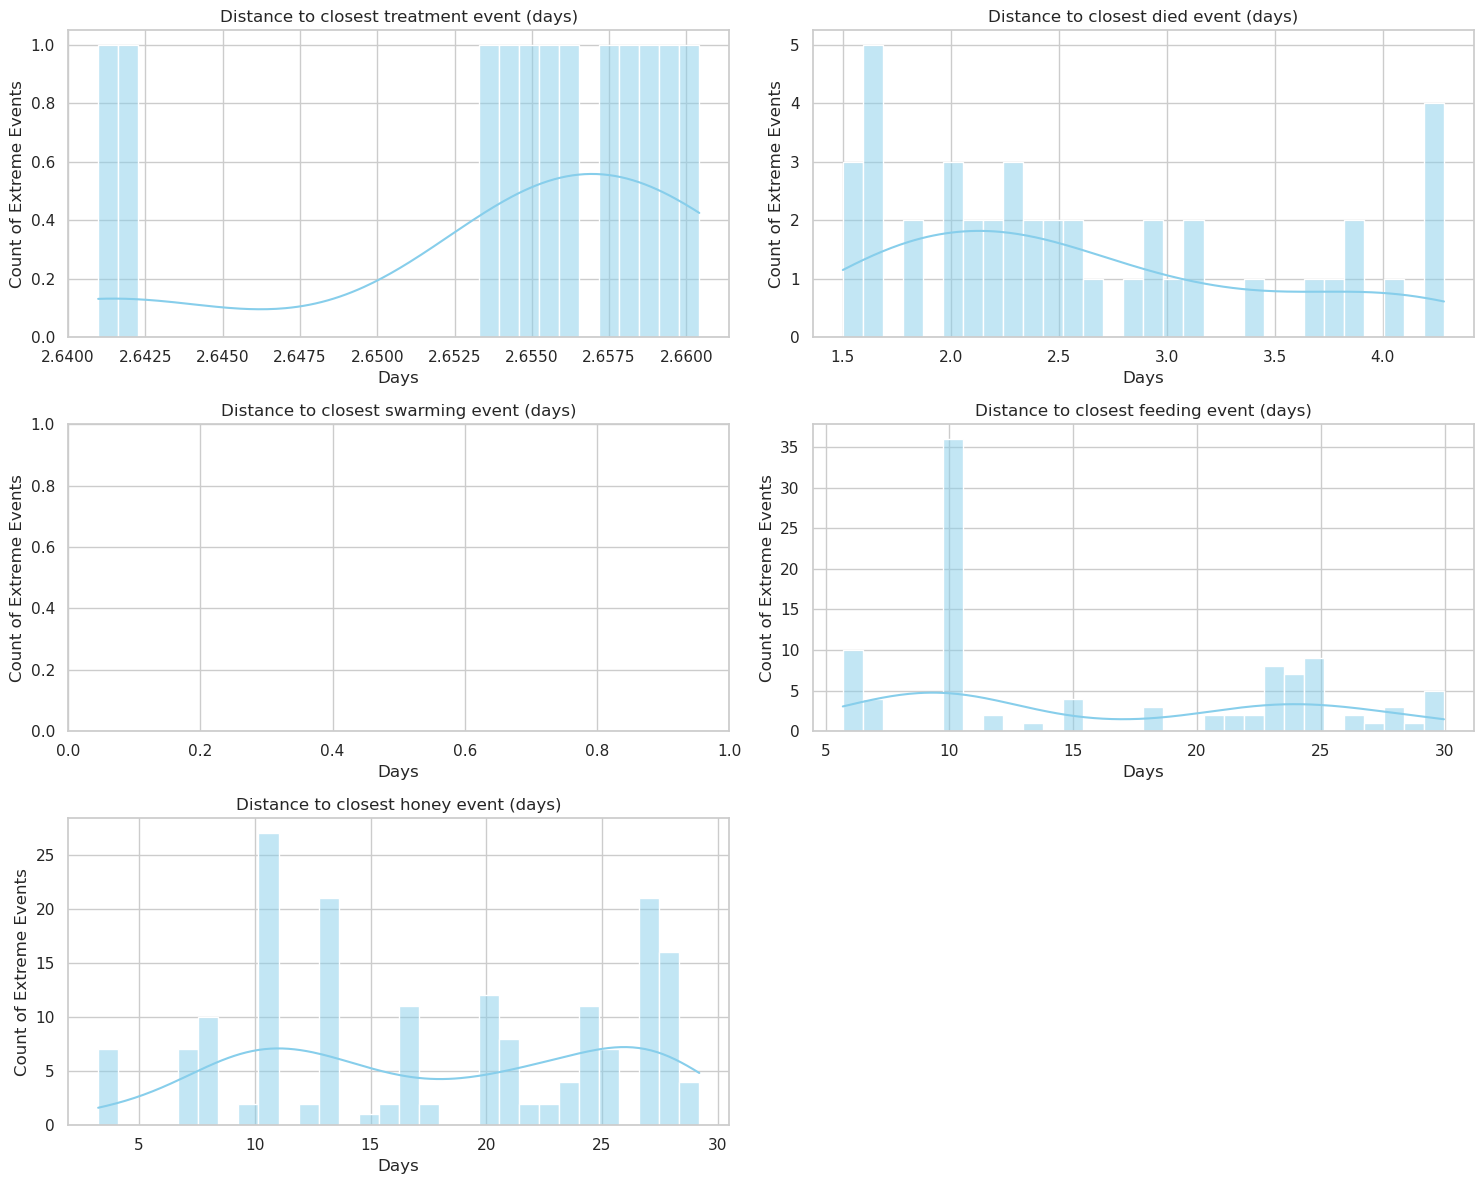

In [3]:
events = ['treatment', 'died', 'swarming', 'feeding', 'honey']

# Calculate the minimum absolute distance to an observation (either before or after)
for event in events:
    last_col = f'{event}_last_dif'
    next_col = f'{event}_next_dif'
    
    # We take the minimum of the absolute distances
    df_extreme[f'{event}_closest_dif'] = np.minimum(
        df_extreme[last_col].abs(), 
        df_extreme[next_col].abs()
    )

# Summary statistics
summary_stats = []
for event in events:
    col = f'{event}_closest_dif'
    valid_data = df_extreme[col].dropna()
    within_1_day = (valid_data <= 1.0).sum()
    within_7_days = (valid_data <= 7.0).sum()
    total = len(valid_data)
    
    if total > 0:
        summary_stats.append({
            'Event': event.capitalize(),
            'Median Dist (days)': valid_data.median(),
            'Mean Dist (days)': valid_data.mean(),
            '% Within 1 Day': (within_1_day / total) * 100,
            '% Within 7 Days': (within_7_days / total) * 100,
            'Total Annotated Extremes': total
        })

stats_df = pd.DataFrame(summary_stats)
display(stats_df.round(2))

# Plot distributions
plt.figure(figsize=(15, 12))
for i, event in enumerate(events, 1):
    plt.subplot(3, 2, i)
    col = f'{event}_closest_dif'
    valid_data = df_extreme[col].dropna()
    
    # Filter out values > 30 days for better visualization of the local effect
    local_data = valid_data[valid_data <= 30]
    
    sns.histplot(local_data, bins=30, kde=True, color='skyblue')
    plt.title(f'Distance to closest {event} event (days)')
    plt.xlabel('Days')
    plt.ylabel('Count of Extreme Events')

plt.tight_layout()
plt.show()

## 3. Date Clustering of Extreme Events

We group the extreme events by date to see if they concentrate on specific days across multiple hives (suggesting an external cause like weather or apiary-level activity), or if they are spread evenly.

Top 10 dates with most extreme events:


,date,num_extremes,affected_hives
193,2020-04-26,1698,7
357,2020-10-10,1378,5
194,2020-04-27,1215,3
358,2020-10-11,1176,4
421,2020-12-17,1104,3
356,2020-10-09,1060,13
359,2020-10-12,1044,2
355,2020-10-08,1036,4
360,2020-10-13,998,4
857,2022-04-28,988,5


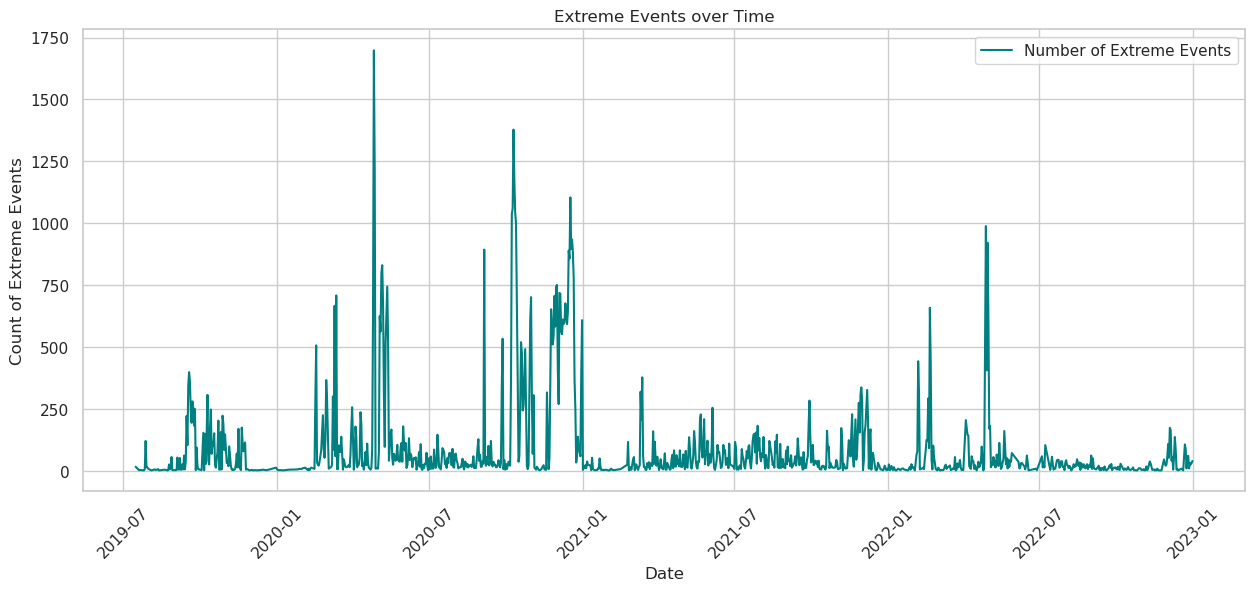

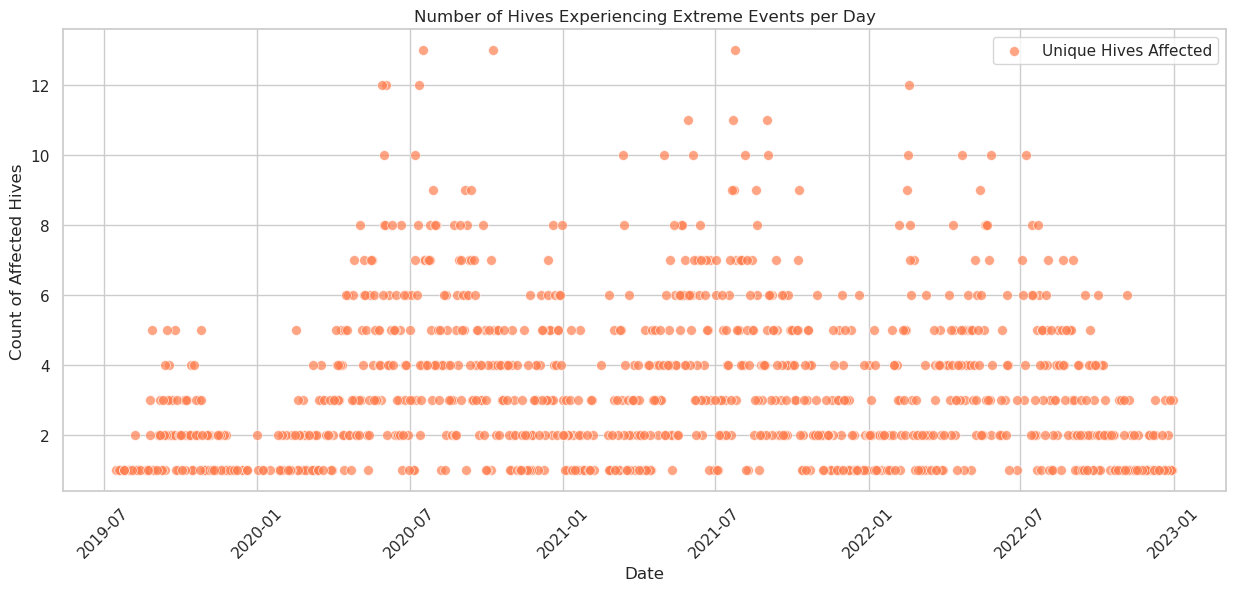

Correlation between number of extremes and number of affected hives on a given day: 0.213

Conclusion: Extreme events are more localized to individual hives.


In [4]:
# Extract date
df_extreme['date'] = df_extreme['time'].dt.date

# Aggregate by date
date_cluster = df_extreme.groupby('date').agg(
    num_extremes=('outlier_lim', 'count'),
    affected_hives=('key', 'nunique')
).reset_index()

date_cluster = date_cluster.sort_values('num_extremes', ascending=False)

print("Top 10 dates with most extreme events:")
display(date_cluster.head(10))

# Plotting the timeline
plt.figure(figsize=(15, 6))
sns.lineplot(data=date_cluster.sort_values('date'), x='date', y='num_extremes', label='Number of Extreme Events', color='teal')
plt.title('Extreme Events over Time')
plt.xlabel('Date')
plt.ylabel('Count of Extreme Events')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Plotting affected hives
plt.figure(figsize=(15, 6))
sns.scatterplot(data=date_cluster, x='date', y='affected_hives', color='coral', alpha=0.7, s=50, label='Unique Hives Affected')
plt.title('Number of Hives Experiencing Extreme Events per Day')
plt.xlabel('Date')
plt.ylabel('Count of Affected Hives')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Correlation between total events and affected hives
corr = date_cluster['num_extremes'].corr(date_cluster['affected_hives'])
print(f"Correlation between number of extremes and number of affected hives on a given day: {corr:.3f}")
if corr > 0.7:
    print("\nConclusion: High clustering observed. When there are many extreme events, they typically affect many hives simultaneously, strongly pointing to external or environmental causes.")
else:
    print("\nConclusion: Extreme events are more localized to individual hives.")

## Key Findings

Based on the investigation, we found the following regarding extreme events ():

1. **No Correlation with Beekeeper Observations:** Extreme weight jumps do not correlate with logged beekeeper observations (treatment, colony death, swarming, feeding, or honey harvest). 0% of extreme events occur within 1 day of an observation, and <2% occur within 7 days.
2. **Highly Localized (No Significant Date Clustering):** Extreme events do not strongly cluster across multiple hives on the same dates (correlation between the number of extremes and affected hives is only 0.213). This suggests that extreme events are localized to individual hives rather than being driven by broad external apiary-level factors like weather.
